In [1]:
import os
import sys

# Add project root to sys.path (one level up from current working directory)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Standard libraries
import numpy as np
import pandas as pd

# Third-party libraries
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn.manifold import TSNE
from sklearn import metrics
from rdkit import Chem
from rdkit.Chem import Draw

# Local application imports
from scripts.pipeline import analyse_score, score_unmeasured_compounds

Compute the xSAR model for a provided chemical space 

In [2]:
lateral_OriginalRefined_path = '../data/1_OriginalRefined-957_BeforeReevaluation/Lateral_OriginalRefined-957_BeforeReevaluation.csv'
lateral_OriginalRefined_df = pd.read_csv(lateral_OriginalRefined_path)
lateral_OriginalRefined_xsar = analyse_score(lateral_OriginalRefined_df)

Flag potential false negatives (i.e: are not initial binders & PBS = 1 & NBS = 1)

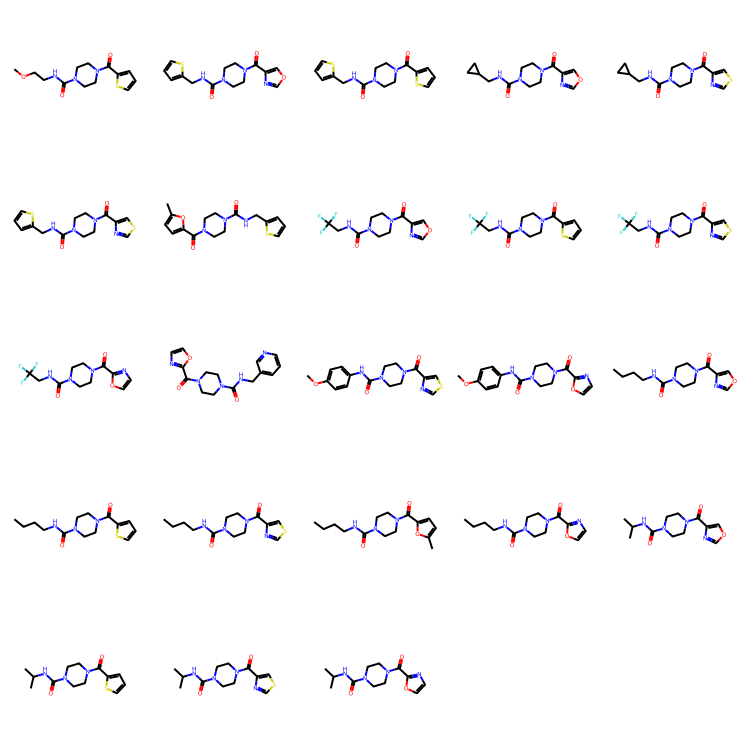

In [3]:
lateral_xsar_subdf = lateral_OriginalRefined_xsar.loc['Compound']
lateral_predicted_FN = lateral_xsar_subdf.loc[(lateral_xsar_subdf[('Reference', 'Binding')] == False) &
                               (lateral_xsar_subdf[('Predictions', 'Positive binding score')] == 1) &
                               (lateral_xsar_subdf[('Predictions', 'Negative binding score')] == 1) ]
# Extract SMILES and convert to RDKit molecules
lateral_predicted_FN_list = lateral_predicted_FN[('Reference', 'Smiles')].tolist()
lateral_predicted_FN_mols = [Chem.MolFromSmiles(sm) for sm in lateral_predicted_FN_list if Chem.MolFromSmiles(sm) is not None]

# Generate and display the image grid
img = Draw.MolsToGridImage(
    lateral_predicted_FN_mols,
    molsPerRow=5,
    subImgSize=(150, 150),
)

img

Reduce fingerprint dimensionality and plot the chemical space along with scores

/Users/haroldgrosjean/miniconda3/envs/xsar/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


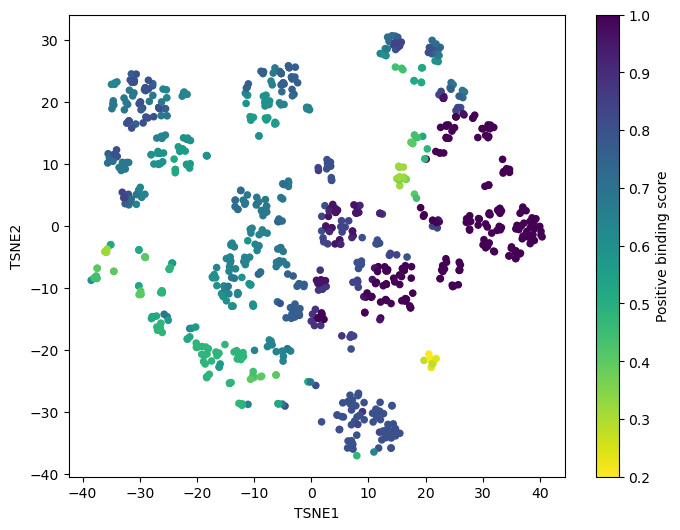

In [4]:
lateral_embedded_compounds = TSNE(n_components=2, metric='jaccard', perplexity=30,
                              learning_rate='auto', init='random', random_state=69).fit_transform(lateral_xsar_subdf['Fingerprint'])

lateral_TNSE_df = pd.DataFrame()
lateral_TNSE_df['TSNE1'] = lateral_embedded_compounds[::,0]
lateral_TNSE_df['TSNE2'] = lateral_embedded_compounds[::,1]
lateral_TNSE_df['PBS'] = lateral_xsar_subdf[('Predictions', 'Positive binding score')]

# Create the plot
plt.figure(figsize=(8, 6))
norm = Normalize(vmin=min(lateral_TNSE_df['PBS']), vmax=max(lateral_TNSE_df['PBS']))  # PBS scores between 0 and 1

ax_tsne = sns.scatterplot(
    data=lateral_TNSE_df,
    x='TSNE1',
    y='TSNE2',
    hue='PBS',
    palette='viridis_r',
    hue_norm=norm,
    linewidth=0,
    s=30  # point size
)
ax_tsne.legend_.remove()  # remove automatic legend
# Add colorbar
sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax_tsne)
cbar.set_label("Positive binding score")

Build the xSAR model, score an external dataset and report performance

In [5]:
# Load datasets
lateral_train_df = pd.read_csv("../data/4_MethodsBenchmarcking/Lateral_train.csv", index_col=0)
lateral_test_df = pd.read_csv("../data/4_MethodsBenchmarcking/Lateral_test.csv", index_col=0)

# Format test data
test_X = lateral_test_df[['Name', 'Smiles']]
test_Y = lateral_test_df['Binding'].astype(bool)

# Score test compounds using SAR profile learned from train set
scored_test = score_unmeasured_compounds(df_reference=lateral_train_df, df_to_score=lateral_test_df)
# Compute and print the PR AUC
PBS_test = scored_test[('Predictions', 'Positive binding score')]
precisions, recalls, thresholds = metrics.precision_recall_curve(test_Y, PBS_test)
PR_auc = metrics.auc(recalls, precisions)
print(PR_auc)

0.7116841448897454
